# **9.Daily Temperature - Linear Regreesion (MSE-2)**

---

**Machine learning and ANN_2025-26_IV_B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---

In [1]:
csv_path=r"D:\Practice-Programs\ANN-ML\ANN-ML-MSE2\09_daily_temperature.csv"
print(csv_path)

D:\Practice-Programs\ANN-ML\ANN-ML-MSE2\09_daily_temperature.csv


In [2]:
import pandas as pd

df=pd.read_csv(csv_path)
print(df.columns)

Index(['day', 'temp_c', 'humidity_pct', 'wind_kmh', 'next_day_temp'], dtype='object')


In [3]:
df.drop(['day'],axis=1,inplace=True)

In [4]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3 - Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outlier_mask=((df < lower_bound) | (df > upper_bound)).any(axis=1)
outliers=df[outlier_mask]

print("Outliers detected:",len(outliers))
print("Outlier rows:")
print(outliers)

df=df[~outlier_mask].reset_index(drop=True)
print("Shape after outlier removal:", df.shape)

Outliers detected:

 1
Outlier rows:
     temp_c  humidity_pct  wind_kmh  next_day_temp
426   26.88          61.3      39.6          27.25
Shape after outlier removal: (729, 4)


In [5]:
X=df.drop(['next_day_temp'],axis=1)
y=df['next_day_temp']

In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_predict=model.predict(X_test_scaled)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 2.979616099469609
R2 Score: 0.9446128833828289


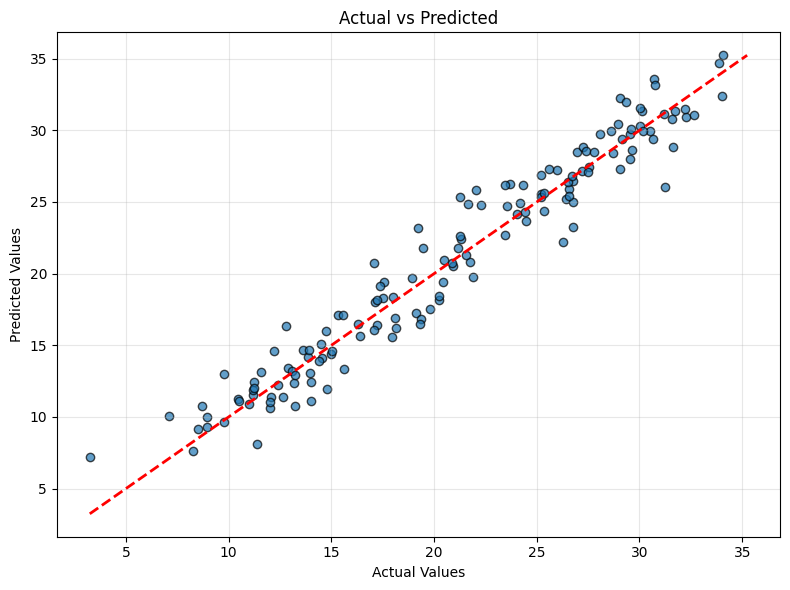

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict, alpha=0.7, edgecolors="k")

min_val = min(y_test.min(), y_predict.min())
max_val = max(y_test.max(), y_predict.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.title("Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()